In [1]:
import torch
import numpy as np
import random

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
import pandas as pd
import numpy as np
import torch


In [3]:
# Paper parameters
M = 49        # VNFs (grid cells)
N = 6         # time window
H = W = 7     # grid size


In [4]:
import pandas as pd
import os

data_path = "/content/drive/MyDrive/milano_project/data/"

files = [
    "sms-call-internet-mi-2013-11-01.txt",
    "sms-call-internet-mi-2013-11-02.txt",
    "sms-call-internet-mi-2013-11-03.txt",
    "sms-call-internet-mi-2013-11-04.txt",
    "sms-call-internet-mi-2013-11-05.txt",
    "sms-call-internet-mi-2013-11-06.txt",
    "sms-call-internet-mi-2013-11-07.txt",
]

dfs = []

for f in files:
    print("Loading:", f)
    df_tmp = pd.read_csv(
        os.path.join(data_path, f),
        sep="\t",
        header=None,
        usecols=[0,1,3]  # square_id, timestamp, internet
    )
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

df.columns = ["square_id", "timestamp", "internet"]
df = df.sort_values(["timestamp", "square_id"]).reset_index(drop=True)


Loading: sms-call-internet-mi-2013-11-01.txt
Loading: sms-call-internet-mi-2013-11-02.txt
Loading: sms-call-internet-mi-2013-11-03.txt
Loading: sms-call-internet-mi-2013-11-04.txt
Loading: sms-call-internet-mi-2013-11-05.txt
Loading: sms-call-internet-mi-2013-11-06.txt
Loading: sms-call-internet-mi-2013-11-07.txt


In [5]:
# DATA_PATH = "/content/drive/MyDrive/milano_project/data/sms-call-internet-mi-2013-11-01.txt"

# columns = [
#     "square_id",
#     "timestamp",
#     "sms_in",
#     "sms_out",
#     "call_in",
#     "call_out",
#     "internet"
# ]

# df = pd.read_csv(DATA_PATH, sep="\t", names=columns)
# df.head()


In [6]:
# Replace missing values with 0
df.fillna(0, inplace=True)

# Ensure correct types
df["square_id"] = df["square_id"].astype(int)
df["timestamp"] = df["timestamp"].astype(int)
df["internet"] = df["internet"].astype(float)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35097595 entries, 0 to 35097594
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   square_id  int64  
 1   timestamp  int64  
 2   internet   float64
dtypes: float64(1), int64(2)
memory usage: 803.3 MB


In [7]:
top_squares = (
    df.groupby("square_id")["internet"]
      .sum()
      .sort_values(ascending=False)
      .head(M)
      .index
)

df = df[df["square_id"].isin(top_squares)]


In [8]:
# Sort by time
df = df.sort_values(["timestamp", "square_id"])

times = sorted(df["timestamp"].unique())
square_to_idx = {sq: i for i, sq in enumerate(top_squares)}

traffic = np.zeros((len(times), M))

for _, row in df.iterrows():
    t_idx = times.index(row["timestamp"])
    m_idx = square_to_idx[row["square_id"]]
    traffic[t_idx, m_idx] = row["internet"]

traffic.shape



(1008, 49)

In [9]:
traffic_min = traffic.min(axis=0)
traffic_max = traffic.max(axis=0)

traffic_norm = (traffic - traffic_min) / (traffic_max - traffic_min + 1e-6)


In [10]:
def create_windows(data, N):
    X, y = [], []
    for t in range(N, len(data)):
        X.append(data[t-N:t])
        y.append(data[t])
    return np.array(X), np.array(y)

X, y = create_windows(traffic_norm, N)

X.shape, y.shape


((1002, 6, 49), (1002, 49))

In [11]:
X = X.reshape(-1, N, H, W)
X = np.transpose(X, (0, 2, 3, 1))   # (batch, 7, 7, N)

X = torch.tensor(X).float()
y = torch.tensor(y).float()

X.shape, y.shape


(torch.Size([1002, 7, 7, 6]), torch.Size([1002, 49]))

In [12]:
X_cnn = X.permute(0, 3, 1, 2)   # [batch, 6, 7, 7]
X_cnn = X_cnn.unsqueeze(1)     # [batch, 1, 6, 7, 7]

X_cnn.shape


torch.Size([1002, 1, 6, 7, 7])

In [13]:
import torch.nn as nn
import torch.nn.functional as F


In [14]:
class EdgeFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv3d(
            in_channels=1,
            out_channels=16,
            kernel_size=(3, 3, 3),
            padding=1
        )

        self.conv2 = nn.Conv3d(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3, 3),
            padding=1
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        return x


# class EdgeFeatureExtractor(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.conv1 = nn.Conv3d(
#             in_channels=1,
#             out_channels=8,   # reduced
#             kernel_size=3,
#             padding=1
#         )

#         self.conv2 = nn.Conv3d(
#             in_channels=8,
#             out_channels=8,   # reduced
#             kernel_size=3,
#             padding=1
#         )

#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         return x



In [15]:
# class EdgePredictor(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.fc1 = nn.Linear(32 * 6 * 7 * 7, 128)
#         self.fc2 = nn.Linear(128, 49)

#     def forward(self, x):
#         x = x.view(x.size(0), -1)  # flatten
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x


class EdgePredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 6 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 49)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



In [16]:
class EdgeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = EdgeFeatureExtractor()
        self.predictor = EdgePredictor()

    def forward(self, x):
        z = self.feature_extractor(x)
        yL = self.predictor(z)
        return yL, z


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_edge = EdgeModel().to(device)
X_cnn = X_cnn.to(device)


In [18]:
yL, z = model_edge(X_cnn)

yL.shape, z.shape


(torch.Size([1002, 49]), torch.Size([1002, 32, 6, 7, 7]))

In [19]:
def sla_cost(y_pred, y_true, c_u=10.0, c_o=1.0):
    """
    SLA-aware cost function from the paper
    y_pred: predicted allocation (batch, 49)
    y_true: true demand (batch, 49)
    """
    under_provision = (y_pred < y_true).float()
    over_provision = (y_pred >= y_true).float()

    cost_under = under_provision * c_u
    cost_over = over_provision * c_o * (y_pred - y_true)

    cost = cost_under + cost_over
    return cost.mean()


In [20]:
y = y.to(device)


In [21]:
import torch.optim as optim

optimizer = optim.Adam(model_edge.parameters(), lr=1e-3)


In [22]:
num_epochs = 25

for epoch in range(num_epochs):
    model_edge.train()

    optimizer.zero_grad()

    # Forward pass
    y_pred, _ = model_edge(X_cnn)

    # Compute SLA-aware loss
    loss = sla_cost(y_pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")


Epoch [1/25] - Loss: 5.2193
Epoch [2/25] - Loss: 7.2719
Epoch [3/25] - Loss: 7.7033
Epoch [4/25] - Loss: 7.5006
Epoch [5/25] - Loss: 7.4977
Epoch [6/25] - Loss: 7.5635
Epoch [7/25] - Loss: 8.4397
Epoch [8/25] - Loss: 8.7680
Epoch [9/25] - Loss: 8.8054
Epoch [10/25] - Loss: 9.1385
Epoch [11/25] - Loss: 9.6097
Epoch [12/25] - Loss: 9.4451
Epoch [13/25] - Loss: 9.0901
Epoch [14/25] - Loss: 9.6256
Epoch [15/25] - Loss: 9.9872
Epoch [16/25] - Loss: 9.9992
Epoch [17/25] - Loss: 9.9226
Epoch [18/25] - Loss: 9.7750
Epoch [19/25] - Loss: 9.9432
Epoch [20/25] - Loss: 9.9998
Epoch [21/25] - Loss: 9.9992
Epoch [22/25] - Loss: 9.9980
Epoch [23/25] - Loss: 9.9961
Epoch [24/25] - Loss: 9.9984
Epoch [25/25] - Loss: 9.9994


In [23]:
# class CloudModel(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.conv1 = nn.Conv3d(
#             in_channels=32,
#             out_channels=64,
#             kernel_size=(3, 3, 3),
#             padding=1
#         )

#         self.conv2 = nn.Conv3d(
#             in_channels=64,
#             out_channels=64,
#             kernel_size=(3, 3, 3),
#             padding=1
#         )

#         self.fc1 = nn.Linear(64 * 6 * 7 * 7, 256)
#         self.fc2 = nn.Linear(256, 49)

#     def forward(self, z):
#         x = F.relu(self.conv1(z))
#         x = F.relu(self.conv2(x))
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         yR = self.fc2(x)
#         return yR





import torch.nn as nn
import torch.nn.functional as F

class CloudModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Deeper and wider conv stack
        self.conv1 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(128, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

        # Much larger fully connected stack
        self.fc1 = nn.Linear(128 * 6 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 49)

    def forward(self, z):
        x = self.relu(self.conv1(z))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))

        yR = self.fc3(x)
        return yR


In [24]:
model_cloud = CloudModel().to(device)
nn.init.constant_(model_cloud.fc3.bias, 0.5)



Parameter containing:
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0', requires_grad=True)

In [25]:
optimizer = optim.Adam(
    list(model_edge.parameters()) + list(model_cloud.parameters()),
    lr=1e-3
)


In [26]:
mse = torch.nn.MSELoss()

for epoch in range(5):
    optimizer.zero_grad()
    yL, z = model_edge(X_cnn)
    yR = model_cloud(z)
    loss = mse(yR, y)
    loss.backward()
    optimizer.step()
    print(f"Warmup Epoch {epoch+1} - MSE: {loss.item():.4f}")


Warmup Epoch 1 - MSE: 0.2331
Warmup Epoch 2 - MSE: 0.1922
Warmup Epoch 3 - MSE: 0.0797
Warmup Epoch 4 - MSE: 0.0562
Warmup Epoch 5 - MSE: 0.0304


In [27]:
def joint_sla_cost(yL, yR, y_true, alpha=0.5):
    CL = sla_cost(yL, y_true)
    CR = sla_cost(yR, y_true)
    return alpha * CL + (1 - alpha) * CR


In [28]:
# num_epochs = 30
# alpha = 0.1

# for epoch in range(num_epochs):
#     model_edge.train()
#     model_cloud.train()

#     optimizer.zero_grad()

#     # Edge forward
#     yL, z = model_edge(X_cnn)

#     # Cloud forward
#     yR = model_cloud(z)

#     # Joint SLA-aware loss
#     loss = joint_sla_cost(yL, yR, y, alpha)

#     # Backpropagation
#     loss.backward()
#     optimizer.step()

#     print(f"Epoch [{epoch+1}/{num_epochs}] - Joint Loss: {loss.item():.4f}")




num_epochs =30
alpha = 0.1

for epoch in range(num_epochs):
    model_edge.train()
    model_cloud.train()

    optimizer.zero_grad()

    # Edge forward
    yL, z = model_edge(X_cnn)

    # Cloud forward
    yR = model_cloud(z)

    # Smooth MSE loss
    mse_loss = F.mse_loss(yL, y) + F.mse_loss(yR, y)

    # SLA loss
    sla_loss = joint_sla_cost(yL, yR, y, alpha)

    # Combined loss
    loss = mse_loss + 0.1 * sla_loss

    # Backprop
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")


Epoch [1/30] - Loss: 0.7689
Epoch [2/30] - Loss: 0.3090
Epoch [3/30] - Loss: 0.4885
Epoch [4/30] - Loss: 0.6949
Epoch [5/30] - Loss: 0.5181
Epoch [6/30] - Loss: 0.3300
Epoch [7/30] - Loss: 0.5486
Epoch [8/30] - Loss: 0.7650
Epoch [9/30] - Loss: 0.5770
Epoch [10/30] - Loss: 0.3476
Epoch [11/30] - Loss: 0.4534
Epoch [12/30] - Loss: 0.7451
Epoch [13/30] - Loss: 0.6676
Epoch [14/30] - Loss: 0.3683
Epoch [15/30] - Loss: 0.3728
Epoch [16/30] - Loss: 0.6854
Epoch [17/30] - Loss: 0.7694
Epoch [18/30] - Loss: 0.3746
Epoch [19/30] - Loss: 0.3889
Epoch [20/30] - Loss: 0.6503
Epoch [21/30] - Loss: 0.7541
Epoch [22/30] - Loss: 0.5482
Epoch [23/30] - Loss: 0.3521
Epoch [24/30] - Loss: 0.5794
Epoch [25/30] - Loss: 0.7319
Epoch [26/30] - Loss: 0.6360
Epoch [27/30] - Loss: 0.3547
Epoch [28/30] - Loss: 0.4695
Epoch [29/30] - Loss: 0.8129
Epoch [30/30] - Loss: 0.5972


In [29]:
model_edge.eval()
model_cloud.eval()

with torch.no_grad():
    yL, z = model_edge(X_cnn)
    yR = model_cloud(z)


In [30]:
def sla_cost_per_sample(y_pred, y_true, c_u=10.0, c_o=1.0):
    under = (y_pred < y_true).float()
    over = (y_pred >= y_true).float()
    cost = under * c_u + over * c_o * (y_pred - y_true)
    return cost.mean(dim=1)  # cost per sample


In [31]:
CL = sla_cost_per_sample(yL, y)
CR = sla_cost_per_sample(yR, y)

CL.shape, CR.shape


(torch.Size([1002]), torch.Size([1002]))

In [32]:
# ---- Soft RTT modeling (paper-style) ----

lambda_rtt = 0.02   # latency weight (tune this later)
RTT_cloud = 30      # current RTT value (change for experiments)

# Effective cloud cost including latency penalty
CR_effective = CR + lambda_rtt * RTT_cloud

# Offloading decision based on total cost comparison
offload = (CL > CR_effective).int()

# Compute offloading rate
offload_rate = offload.float().mean().item()

print("Offloading rate:", offload_rate)


Offloading rate: 0.9840319156646729


In [33]:
# b = CL - CR


In [34]:
# offload = (b > 0).int()  # 1 = cloud, 0 = edge


In [35]:
# offload_rate = offload.float().mean().item()
# offload_rate


In [36]:
# RTT_edge = 5    # ms
# RTT_cloud = 20  # ms
# RTT_max = 30    # SLA latency limit


In [37]:
# offload = ((b > 0) & (RTT_cloud <= RTT_max)).int()


In [38]:
# offload.float().mean().item()


In [39]:
print("RTT Sensitivity Analysis")
print("-------------------------")

lambda_rtt = 0.05

for rtt in [10, 20, 30, 40, 50, 60]:
    CR_eff = CR + lambda_rtt * rtt
    offload = (CL > CR_eff).int()
    rate = offload.float().mean().item()
    print(f"RTT = {rtt} ms → Offloading rate = {rate:.3f}")


RTT Sensitivity Analysis
-------------------------
RTT = 10 ms → Offloading rate = 0.984
RTT = 20 ms → Offloading rate = 0.930
RTT = 30 ms → Offloading rate = 0.689
RTT = 40 ms → Offloading rate = 0.408
RTT = 50 ms → Offloading rate = 0.024
RTT = 60 ms → Offloading rate = 0.000


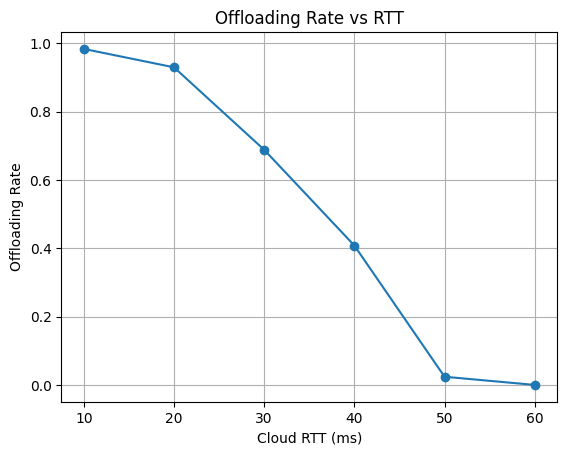

In [40]:
import matplotlib.pyplot as plt

RTT_values = [10, 20, 30, 40, 50, 60]
rates = []

lambda_rtt = 0.05

for rtt in RTT_values:
    CR_eff = CR + lambda_rtt * rtt
    offload = (CL > CR_eff).int()
    rates.append(offload.float().mean().item())

plt.plot(RTT_values, rates, marker='o')
plt.xlabel("Cloud RTT (ms)")
plt.ylabel("Offloading Rate")
plt.title("Offloading Rate vs RTT")
plt.grid(True)
plt.show()


In [41]:
# def decide_execution(yL, yR, y_true, RTT_cloud, RTT_max):
#     CL = sla_cost_per_sample(yL, y_true)
#     CR = sla_cost_per_sample(yR, y_true)
#     b = CL - CR
#     offload = ((b > 0) & (RTT_cloud <= RTT_max)).int()
#     return offload




def decide_execution(yL, yR, y_true, RTT_cloud, lambda_rtt):
    CL = sla_cost_per_sample(yL, y_true)
    CR = sla_cost_per_sample(yR, y_true)

    # Effective cloud cost (paper-style)
    CR_effective = CR + lambda_rtt * RTT_cloud

    offload = (CL > CR_effective).int()
    return offload


In [42]:
import os
import numpy as np

# Make sure results folder exists
results_path = "/content/drive/MyDrive/milano_project/results/"
os.makedirs(results_path, exist_ok=True)

# Save Phase 5 outputs
np.savetxt(results_path + "offloading_decisions.txt", offload.cpu().numpy())
np.savetxt(results_path + "edge_cost.txt", CL.cpu().numpy())
np.savetxt(results_path + "cloud_cost.txt", CR.cpu().numpy())

print("Phase 5 results saved successfully")


Phase 5 results saved successfully
